In [196]:
import numpy as np
import pandas as pd
import netwulf as nw
import networkx as nx
import matplotlib.pyplot as plt

In [197]:
pd.set_option('display.max_rows', 500)

In [198]:
connection_pd = pd.read_csv('./line_station_connectionV1130.csv')
connection_pd

,line_cd,station_cd1,station_cd2,company_cd,line_name,station_name1,station_name2,station_lng1,station_lng2,station_lat1,station_lat2,dc:title,odpt:lineCode,odpt:operator,line,odpt_railway,Con,distance
0,11302,1194,976,2,JR山手線,大崎,五反田,139.728439,139.723822,35.619772,35.625974,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,0.735128
1,11302,976,1661,2,JR山手線,五反田,目黒,139.723822,139.715775,35.625974,35.633923,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.120418
2,11302,1661,1885,2,JR山手線,目黒,恵比寿,139.715775,139.710070,35.633923,35.646685,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.254671
3,11302,1885,725,2,JR山手線,恵比寿,渋谷,139.710070,139.701238,35.646685,35.658871,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.425703
4,11302,725,1663,2,JR山手線,渋谷,原宿,139.701238,139.702592,35.658871,35.670646,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.009891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1489,99343,524,889,130,グリーンライン,センター北,北山田,139.578386,139.592258,35.553534,35.561077,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.669461
1490,99343,889,1714,130,グリーンライン,北山田,東山田,139.592258,139.604369,35.561077,35.554302,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.463786
1491,99343,1714,674,130,グリーンライン,東山田,高田,139.604369,139.619944,35.554302,35.549713,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.774937
1492,99343,674,653,130,グリーンライン,高田,日吉本町,139.619944,139.633554,35.549713,35.549883,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.513431


In [199]:
# list of all the stations in the connection data

station_list_connection_1 = connection_pd[['station_cd1', 'station_name1']].rename(columns={'station_cd1': 'station_id', 'station_name1': 'S12_001'}).drop_duplicates()
station_list_connection_2 = connection_pd[['station_cd2', 'station_name2']].rename(columns={'station_cd2': 'station_id', 'station_name2': 'S12_001'}).drop_duplicates()
station_list_pd = pd.concat([station_list_connection_1, station_list_connection_2]).drop_duplicates().reset_index(drop=True)
station_list_pd

,station_id,S12_001
0,1194,大崎
1,976,五反田
2,1661,目黒
3,1885,恵比寿
4,725,渋谷
...,...,...
1108,424,芝山千代田
1109,1631,松戸
1110,594,羽田空港第2ターミナル
1111,1448,東葉勝田台


In [200]:
# list of all the stations in the passenger survey data that are also in the connection data

passenger_survey_pd = pd.read_csv('./pass_survey_tokyov1109.csv')
passenger_survey_pd['station_id'] = passenger_survey_pd['station_id'].astype(int)
passenger_survey_pd[passenger_survey_pd['station_id'].isin(station_list_pd['station_id'].values)]

matching_passenger_survey_pd = passenger_survey_pd[passenger_survey_pd['station_id'].isin(station_list_pd['station_id'].values)].reset_index(drop=True)

# max-min normalize passenger counts as in the original paper:
year_cols = ['2013', '2014', '2015', '2016', '2017', '2018', '2019']
global_min = matching_passenger_survey_pd[year_cols].min().min()
global_max = matching_passenger_survey_pd[year_cols].max().max()
for year in year_cols:
    matching_passenger_survey_pd[year] = (matching_passenger_survey_pd[year] - global_min) / (global_max - global_min)

matching_passenger_survey_pd = matching_passenger_survey_pd.sort_values('station_id').reset_index(drop=True)
matching_passenger_survey_pd

,S12_001,2013,2014,2015,2016,2017,2018,2019,station_id
0,霞ヶ関,0.040218,0.040281,0.041563,0.042318,0.042762,0.043260,0.042839,2
1,多摩湖,0.000638,0.000613,0.000613,0.000608,0.000623,0.000638,0.000612,3
2,高島町,0.001933,0.002002,0.002065,0.002143,0.002287,0.002512,0.002528,4
3,志村三丁目,0.007439,0.007458,0.007655,0.007866,0.007675,0.007665,0.007701,7
4,印西牧の原,0.003034,0.003004,0.003089,0.003157,0.003246,0.003411,0.003580,9
...,...,...,...,...,...,...,...,...,...
1101,吉川美南,0.000811,0.001112,0.001408,0.001790,0.001970,0.002456,0.002456,2491
1102,富水,0.001649,0.001613,0.001633,0.001621,0.001621,0.001611,0.001608,2492
1103,東福生,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2493
1104,中井,0.012101,0.012105,0.012316,0.012437,0.012919,0.013167,0.013044,2494


In [201]:
# and now we need to make sure nodes in the passenger survey match up with nodes in the connection data
# the passenger_survey_pd only has nodes that are in the station_list_pd, so we can just filter the station_list_pd to only include those nodes

# note that both data had stations that were not in the other

station_list_pd = station_list_pd[station_list_pd['station_id'].isin(matching_passenger_survey_pd['station_id'].values)].reset_index(drop=True)
station_list_pd = station_list_pd.sort_values('station_id').reset_index(drop=True)
station_list_pd

,station_id,S12_001
0,2,霞ヶ関
1,3,多摩湖
2,4,高島町
3,7,志村三丁目
4,9,印西牧の原
...,...,...
1101,2491,吉川美南
1102,2492,富水
1103,2493,東福生
1104,2494,中井


In [202]:
#remove any connections between stations that are not in the station_list_pd
station_node_pd = connection_pd[connection_pd['station_cd1'].isin(station_list_pd['station_id'].values) & connection_pd['station_cd2'].isin(station_list_pd['station_id'].values)][['line', 'station_cd1', 'station_cd2', 'distance']].drop_duplicates()
station_node_pd

,line,station_cd1,station_cd2,distance
0,JR-East.Yamanote,1194,976,0.735128
1,JR-East.Yamanote,976,1661,1.120418
2,JR-East.Yamanote,1661,1885,1.254671
3,JR-East.Yamanote,1885,725,1.425703
4,JR-East.Yamanote,725,1663,1.009891
...,...,...,...,...
1489,YokohamaMunicipal.Green,524,889,1.669461
1490,YokohamaMunicipal.Green,889,1714,1.463786
1491,YokohamaMunicipal.Green,1714,674,1.774937
1492,YokohamaMunicipal.Green,674,653,1.513431


In [203]:
# testing:

first_row = station_node_pd.loc[(station_node_pd['station_cd1'] == 1194) & (station_node_pd['station_cd2'] == 976)]
second_row = station_node_pd.loc[(station_node_pd['station_cd1'] == 976) & (station_node_pd['station_cd2'] == 1194)]
print(first_row)
print(second_row)

               line  station_cd1  station_cd2  distance
0  JR-East.Yamanote         1194          976  0.735128
Empty DataFrame
Columns: [line, station_cd1, station_cd2, distance]
Index: []


In [204]:
# build graph structure using networkx
G = nx.Graph()
G = nx.from_pandas_edgelist(station_node_pd, 'station_cd1', 'station_cd2', edge_attr=True)

node_order = list(G.nodes())
print(f"Number of nodes in G: {len(G.nodes())}")
print(f"Number of edges in G: {len(G.edges())}")

Number of nodes in G: 1106
Number of edges in G: 1285


In [205]:
# we need to make sure the station_list_pd is in the same order as the nodes in the graph G, which is the order the adjacency matrix will use
station_list_pd = station_list_pd.set_index('station_id').loc[node_order].reset_index(drop=False)
station_list_pd

,station_id,S12_001
0,1194,大崎
1,976,五反田
2,1661,目黒
3,1885,恵比寿
4,725,渋谷
...,...,...
1101,790,都筑ふれあいの丘
1102,889,北山田
1103,1714,東山田
1104,674,高田


In [206]:
# and we also need to make sure the passenger survey data is in the same order as the nodes in the graph G, which is the order the adjacency matrix will use
matching_passenger_survey_pd = matching_passenger_survey_pd.set_index('station_id').loc[node_order].reset_index(drop=False)
matching_passenger_survey_pd

,station_id,S12_001,2013,2014,2015,2016,2017,2018,2019
0,1194,大崎,0.065471,0.067878,0.068955,0.073155,0.076126,0.081956,0.081956
1,976,五反田,0.102623,0.103546,0.104375,0.105332,0.107845,0.111082,0.110915
2,1661,目黒,0.107486,0.109963,0.111805,0.112591,0.117658,0.122312,0.122426
3,1885,恵比寿,0.086440,0.088655,0.090444,0.093605,0.096105,0.098302,0.097795
4,725,渋谷,0.586972,0.571573,0.578823,0.581368,0.589753,0.591181,0.640074
...,...,...,...,...,...,...,...,...,...
1101,790,都筑ふれあいの丘,0.004440,0.004547,0.004773,0.004935,0.004988,0.005171,0.005274
1102,889,北山田,0.005942,0.006103,0.006389,0.006530,0.006657,0.006804,0.006732
1103,1714,東山田,0.002177,0.002218,0.002312,0.002438,0.002495,0.002574,0.002482
1104,674,高田,0.005797,0.005408,0.005997,0.006168,0.006219,0.006478,0.006588


(<Figure size 480x480 with 1 Axes>, <Axes: >)

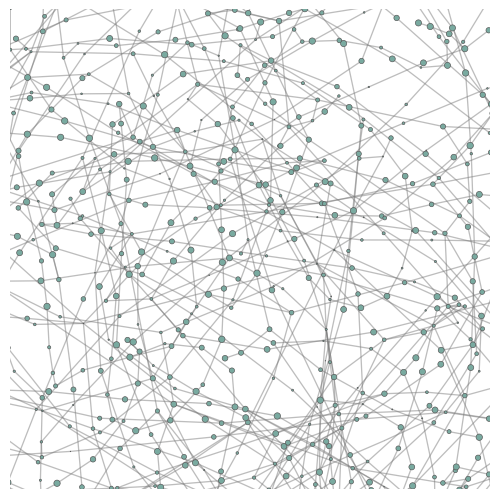

In [207]:
for n, data in G.nodes(data=True):
    data['size'] = np.random.random()

stylized_network, config = nw.visualize(G, plot_in_cell_below=True)

nw.draw_netwulf(stylized_network, config)

In [208]:
#normalize distances
d_max = station_node_pd['distance'].max()
station_node_pd['nor_distance'] = station_node_pd['distance'].apply(lambda x: (x - 0.1) / (d_max - 0.1))
station_node_pd

,line,station_cd1,station_cd2,distance,nor_distance
0,JR-East.Yamanote,1194,976,0.735128,0.048421
1,JR-East.Yamanote,976,1661,1.120418,0.077795
2,JR-East.Yamanote,1661,1885,1.254671,0.088030
3,JR-East.Yamanote,1885,725,1.425703,0.101069
4,JR-East.Yamanote,725,1663,1.009891,0.069368
...,...,...,...,...,...
1489,YokohamaMunicipal.Green,524,889,1.669461,0.119653
1490,YokohamaMunicipal.Green,889,1714,1.463786,0.103972
1491,YokohamaMunicipal.Green,1714,674,1.774937,0.127694
1492,YokohamaMunicipal.Green,674,653,1.513431,0.107757


In [209]:
#get operator name from line name
#TODO this could be redundant, could just directly get operator instead
station_node_pd['operator'] = station_node_pd['line'].apply(lambda x: x.split('.')[0])
station_node_pd

,line,station_cd1,station_cd2,distance,nor_distance,operator
0,JR-East.Yamanote,1194,976,0.735128,0.048421,JR-East
1,JR-East.Yamanote,976,1661,1.120418,0.077795,JR-East
2,JR-East.Yamanote,1661,1885,1.254671,0.088030,JR-East
3,JR-East.Yamanote,1885,725,1.425703,0.101069,JR-East
4,JR-East.Yamanote,725,1663,1.009891,0.069368,JR-East
...,...,...,...,...,...,...
1489,YokohamaMunicipal.Green,524,889,1.669461,0.119653,YokohamaMunicipal
1490,YokohamaMunicipal.Green,889,1714,1.463786,0.103972,YokohamaMunicipal
1491,YokohamaMunicipal.Green,1714,674,1.774937,0.127694,YokohamaMunicipal
1492,YokohamaMunicipal.Green,674,653,1.513431,0.107757,YokohamaMunicipal


In [210]:
#let's color lines by operator

operators_list = station_node_pd['operator'].unique()
operators_list.sort()
print("Operators:", operators_list)

colors = range(len(station_node_pd['operator'].unique()))
N=len(colors)

cmap = plt.get_cmap("Set3_r")
cmap_list=[]
for i in range(N):
    c=cmap(float(i)/N)
    cmap_list.append(c)

line_color=dict(zip(operators_list,cmap_list))

line_color

Operators: ['Hokuso' 'JR-East' 'Keikyu' 'Keio' 'Keisei' 'Minatomirai' 'Odakyu'
 'SaitamaRailway' 'Seibu' 'Shibayama' 'ShinKeisei' 'Sotetsu' 'TWR' 'Tobu'
 'Toei' 'TokyoMetro' 'TokyoMonorail' 'Tokyu' 'ToyoRapid'
 'YokohamaMunicipal' 'Yurikamome']


{'Hokuso': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0),
 'JR-East': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0),
 'Keikyu': (0.8, 0.9215686274509803, 0.7725490196078432, 1.0),
 'Keio': (0.8, 0.9215686274509803, 0.7725490196078432, 1.0),
 'Keisei': (0.7372549019607844, 0.5019607843137255, 0.7411764705882353, 1.0),
 'Minatomirai': (0.7372549019607844,
  0.5019607843137255,
  0.7411764705882353,
  1.0),
 'Odakyu': (0.8509803921568627, 0.8509803921568627, 0.8509803921568627, 1.0),
 'SaitamaRailway': (0.9882352941176471,
  0.803921568627451,
  0.8980392156862745,
  1.0),
 'Seibu': (0.9882352941176471, 0.803921568627451, 0.8980392156862745, 1.0),
 'Shibayama': (0.7019607843137254,
  0.8705882352941177,
  0.4117647058823529,
  1.0),
 'ShinKeisei': (0.7019607843137254,
  0.8705882352941177,
  0.4117647058823529,
  1.0),
 'Sotetsu': (0.9921568627450981, 0.7058823529411765, 0.3843137254901961, 1.0),
 'TWR': (0.9921568627450981, 0.7058823529411765, 0.3843137254901961, 1.0),
 'Tobu

In [211]:
for link in stylized_network['links']:
    
    line = station_node_pd[((station_node_pd['station_cd1'] == link['source']) & (station_node_pd['station_cd2'] == link['target'])) |
                           ((station_node_pd['station_cd1'] == link['target']) & (station_node_pd['station_cd2'] == link['source']))]
    # print(line)
    if len(line) > 0:
        print(line)#operator
        #link['color'] = line_color[line.iloc[0, 4]]
        link['color'] = line_color[line.iloc[0, 5]] # 0 takes the first row and 5 takes the operator column. this is fine since if multiple lines go between two stations just pick one of them for the color
        dis = line.iloc[0, 3]
        if dis < 1.0:
            link['width'] = 5
        elif dis < 2.0:
            link['width'] = 4
        elif dis < 5.0:
            link['width'] = 3
        elif dis < 10.0:
            link['width'] = 2
        else:
            link['width'] = 1
    else:
        print(link)
        # if didn't print link, then all the lines have been found

               line  station_cd1  station_cd2  distance  nor_distance operator
0  JR-East.Yamanote         1194          976  0.735128      0.048421  JR-East
                line  station_cd1  station_cd2  distance  nor_distance  \
28  JR-East.Yamanote         1750         1194  1.400128      0.099119   

   operator  
28  JR-East  
                        line  station_cd1  station_cd2  distance  \
296           JR-East.Saikyo         1194         1885  3.063343   
464   JR-East.ShonanShinjuku         1885         1194  3.063343   
1207        Sotetsu.JRDirect         1885         1194  3.063343   

      nor_distance operator  
296       0.225919  JR-East  
464       0.225919  JR-East  
1207      0.225919  Sotetsu  
                        line  station_cd1  station_cd2  distance  \
465   JR-East.ShonanShinjuku         1194          785  1.711485   
1208        Sotetsu.JRDirect         1194          785  1.711485   

      nor_distance operator  
465       0.122856  JR-East  
1208   

In [212]:
#track stations with no

for node in stylized_network['nodes']:
    sta = passenger_survey_pd[passenger_survey_pd['station_id'] == node['id']] #node id is station name in english
    if sta.shape[0] == 0:
        print(node['id'], sta.shape[0])
    if len(sta) > 0:
        #node['color'] = line_color[station_node_pd[station_node_pd['station_en'] == node['id']].iloc[0, 4]]
        if not station_node_pd[station_node_pd['station_cd1'] == node['id']].empty:
            node['color'] = line_color[station_node_pd[station_node_pd['station_cd1'] == node['id']].iloc[0, 5]]
            sta_mean = sta[['2013', '2014', '2015', '2016', '2017', '2018', '2019']].values.mean()
            if sta_mean < 10000:
                node['radius'] = 1.5
            elif sta_mean < 100000:
                node['radius'] = 2.5
            elif sta_mean < 500000:
                node['radius'] = 4
            elif sta_mean < 1000000:
                node['radius'] = 7
            elif sta_mean < 2000000:
                node['radius'] = 9
            else:
                node['radius'] = 10
        elif not station_node_pd[station_node_pd['station_cd2'] == node['id']].empty: #some stations only appear in station_cd2 column 
            node['color'] = line_color[station_node_pd[station_node_pd['station_cd2'] == node['id']].iloc[0, 5]] 
            sta_mean = sta[['2013', '2014', '2015', '2016', '2017', '2018', '2019']].values.mean()
            if sta_mean < 10000:
                node['radius'] = 1.5
            elif sta_mean < 100000:
                node['radius'] = 2.5
            elif sta_mean < 500000:
                node['radius'] = 4
            elif sta_mean < 1000000:
                node['radius'] = 7
            elif sta_mean < 2000000:
                node['radius'] = 9
            else:
                node['radius'] = 10
    else:
        print("station not found in survey data:", node['id'])
    # highlight major stations in green
    if node['id'] in ['Shibuya', 'Shinjuku', 'Ikebukuro', 'Yokohama', 'Takadanobaba', 'Tokyo', 'Shimbashi', 'Shinagawa']:
        node['color'] = "lawngreen"

for node in stylized_network['nodes']:
    print(node) 
# nw.draw_netwulf(stylized_network, config)

{'id': 1194, 'x': 529.7280014039818, 'y': 709.8300175838759, 'x_canvas': 529.7280014039818, 'y_canvas': 709.8300175838759, 'radius': 4, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}
{'id': 976, 'x': 363.86624895567996, 'y': 618.4621252988968, 'x_canvas': 363.86624895567996, 'y_canvas': 618.4621252988968, 'radius': 4, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}
{'id': 1661, 'x': 423.58380792942694, 'y': 676.0393349384074, 'x_canvas': 423.58380792942694, 'y_canvas': 676.0393349384074, 'radius': 4, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}
{'id': 1885, 'x': 253.18482516000495, 'y': 610.9279117346341, 'x_canvas': 253.18482516000495, 'y_canvas': 610.9279117346341, 'radius': 4, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}
{'id': 725, 'x': -21.416063865615808, 'y': 426.92110693788436, 'x_canvas': -21.416063865615808, 'y_canvas': 426.92110693788436, 'radius': 10, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}

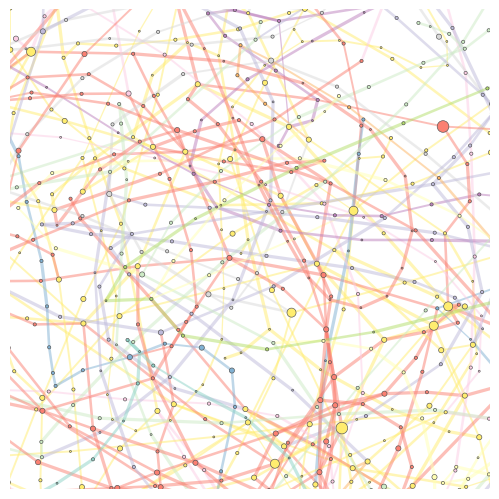

In [213]:
fig, ax = nw.draw_netwulf(stylized_network, config)
plt.show()

In [214]:
print("number of edges:", len(stylized_network['links']))
print("number of nodes:", len(stylized_network['nodes']))
print("passenger count means for stations with more than 500k passengers in 2019:")
for sta in passenger_survey_pd[passenger_survey_pd['2019'] > 2000000].groupby(by='station_id'):
    print(str(sta[0]) + ': {}'.format(sta[1]['2019'].mean()))

number of edges: 1285
number of nodes: 1106
passenger count means for stations with more than 500k passengers in 2019:
277: 2662632.0
725: 2704384.0
1102: 2101709.0
1872: 3265570.0


725 {'group': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0), 'size': 10}


(<Figure size 480x480 with 1 Axes>, <Axes: >)

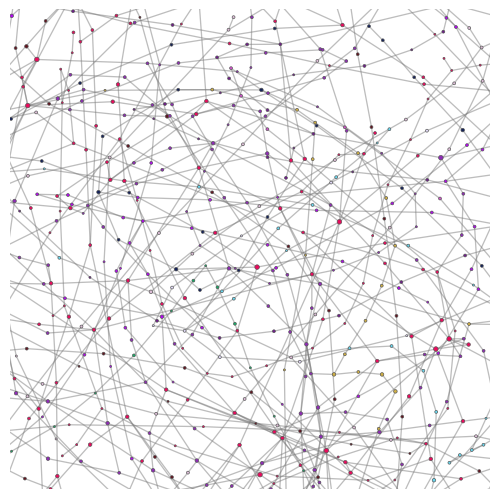

In [215]:
# now let's create a test graph:

test_G = nx.Graph()
test_G = nx.from_pandas_edgelist(station_node_pd, 'station_cd1', 'station_cd2', edge_attr=True)

for k, v in test_G.nodes(data=True):
    v['group'] = line_color[station_node_pd[(station_node_pd['station_cd1'] == k) | (station_node_pd['station_cd2'] == k)].iloc[0, 5]]

for n, data in test_G.nodes(data=True):
    sta = passenger_survey_pd[passenger_survey_pd['station_id'] == n]
    if len(sta) > 0:
        sta_mean = sta[['2013', '2014', '2015', '2016', '2017', '2018', '2019']].values.mean()
        if sta_mean < 10000:
            data['size'] = 1
        elif sta_mean < 100000:
            data['size'] = 2
        elif sta_mean < 500000:
            data['size'] = 3
        else:
            data['size'] = 5
    # elif not station_node_pd[station_node_pd['station_cd2'] == n].empty:
    #     sta = passenger_survey_pd[passenger_survey_pd['station_cd2'] == n]
    #     if len(sta) > 0:
    #         sta_mean = sta[['2013', '2014', '2015', '2016', '2017', '2018', '2019']].values.mean()
    #         if sta_mean < 10000:
    #             data['size'] = 1
    #         elif sta_mean < 100000:
    #             data['size'] = 2
    #         elif sta_mean < 500000:
    #             data['size'] = 3
    #         else:
    #             data['size'] = 5
    else:
        data['size'] = 1
    if n == 725: #Shibuya id is 725
        data['size'] = 10
        print(n, data)
test_return, test_config = nw.visualize(test_G, plot_in_cell_below=True)
nw.draw_netwulf(test_return, test_config)


# print(test_G.edges(data=True))

In [216]:
# let's look at the original graph:

import torch

A = nx.adjacency_matrix(G)
torch_A = torch.tensor(A.todense(), dtype=torch.float)
torch_A

tensor([[0., 1., 0.,  ..., 0., 0., 0.],
        [1., 0., 1.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 1., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.]])

 Getting started with the GNN implementations:

In [217]:
import torch
from torch import nn
from torch_geometric.nn import GCNConv


class GCN(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCN, self).__init__()
        torch.manual_seed(0)
        A = torch.tensor(nx.adjacency_matrix(G).todense())
        A = A + torch.eye(A.size(0))  # Add self-loops
        D = torch.diag(torch.sum(A, dim=1))
        self.A_hat = torch.matmul(torch.matmul(torch.inverse(D), A), torch.inverse(D))  # Symmetric normalization
        self.layer_1 = nn.Linear(in_features, in_features)
        self.layer_2 = nn.Linear(in_features, out_features)
    
    def forward(self, x):
        x = torch.matmul(self.A_hat, x)
        x = self.layer_1(x)
        x = torch.relu(x)
        x = self.layer_2(x)
        return x

In [218]:
model = GCN(in_features=16, out_features=2)
print(model)

GCN(
  (layer_1): Linear(in_features=16, out_features=16, bias=True)
  (layer_2): Linear(in_features=16, out_features=2, bias=True)
)


In [219]:
# Get node ordering from graph G — this is the order the adjacency matrix uses
node_order = list(G.nodes())
print(f"Node order: {node_order[-10:]}...")  # Print first 10 nodes to verify

# Aggregate passenger survey by station_id (handles duplicate rows per station)
survey_filtered = matching_passenger_survey_pd[matching_passenger_survey_pd['station_id'].isin(node_order)]
survey_agg = survey_filtered.groupby('station_id')[['2013','2014','2015','2016','2017','2018','2019']].mean()
print(f"Unique stations in survey after aggregation: {len(survey_agg)}")

Node order: [121, 1007, 565, 1510, 890, 790, 889, 1714, 674, 653]...
Unique stations in survey after aggregation: 1106


In [220]:
#one hot encoding for line and operator

all_operators = sorted(station_node_pd['operator'].unique())
all_lines = sorted(station_node_pd['line'].unique())

node_operator_df = pd.DataFrame(0, index=node_order, columns=all_operators)
node_line_df = pd.DataFrame(0, index=node_order, columns=all_lines)

for _, row in station_node_pd.iterrows():
    for node_col in ['station_cd1', 'station_cd2']:
        node = row[node_col]
        if node in node_operator_df.index:
            node_operator_df.loc[node, row['operator']] = 1
        if node in node_line_df.index:
            node_line_df.loc[node, row['line']] = 1

operator_features = torch.tensor(node_operator_df.values, dtype=torch.float)
line_features = torch.tensor(node_line_df.values, dtype=torch.float)

In [221]:
# Reorder features to match graph node ordering
train_x = torch.tensor(survey_agg.loc[node_order][['2013', '2014', '2015', '2016', '2017']].to_numpy(), dtype=torch.float)
train_x = torch.cat([train_x, operator_features, line_features], dim=1)  # Concatenate all features
train_y = torch.tensor(survey_agg.loc[node_order][['2018']].to_numpy(), dtype=torch.float)

print(f"train_x shape: {train_x.shape}, train_y shape: {train_y.shape}")
train_x, train_y

train_x shape: torch.Size([1106, 121]), train_y shape: torch.Size([1106, 1])


(tensor([[0.0655, 0.0679, 0.0690,  ..., 0.0000, 0.0000, 0.0000],
         [0.1026, 0.1035, 0.1044,  ..., 0.0000, 0.0000, 0.0000],
         [0.1075, 0.1100, 0.1118,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0022, 0.0022, 0.0023,  ..., 0.0000, 1.0000, 0.0000],
         [0.0058, 0.0054, 0.0060,  ..., 0.0000, 1.0000, 0.0000],
         [0.0033, 0.0034, 0.0035,  ..., 0.0000, 1.0000, 0.0000]]),
 tensor([[0.0820],
         [0.1111],
         [0.1223],
         ...,
         [0.0026],
         [0.0065],
         [0.0039]]))

In [222]:
# Use same node_order and survey_agg from above
test_x = torch.tensor(survey_agg.loc[node_order][['2014', '2015', '2016', '2017', '2018']].to_numpy(), dtype=torch.float)
test_x = torch.cat([test_x, operator_features, line_features], dim=1)  # Concatenate all features
test_y = torch.tensor(survey_agg.loc[node_order][['2019']].to_numpy(), dtype=torch.float)

print(f"test_x shape: {test_x.shape}, test_y shape: {test_y.shape}")
# Verify train and test inputs are different
print(f"train_x and test_x are identical: {torch.equal(train_x, test_x)}")

test_x shape: torch.Size([1106, 121]), test_y shape: torch.Size([1106, 1])
train_x and test_x are identical: False


In [227]:
model = GCN(in_features=train_x.shape[1], out_features=train_y.shape[1])
criterion = nn.functional.l1_loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Convert graph to proper edge_index format: [2, num_edges] LongTensor
adj = nx.adjacency_matrix(G)
rows, cols = adj.nonzero()
edge_index = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
print(f"edge_index shape: {edge_index.shape} (expected [2, num_edges])")

def train(x, y):
    model.train()
    optimizer.zero_grad()
    out = model(x)
    loss = criterion(out, y)
    loss.backward()
    optimizer.step()
    return loss

edge_index shape: torch.Size([2, 2570]) (expected [2, num_edges])


In [228]:

for epoch in range(500):
    loss = train(train_x, train_y)
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.10f}")

Epoch 20, Loss: 0.0138937728
Epoch 40, Loss: 0.0124368053
Epoch 60, Loss: 0.0121976426
Epoch 80, Loss: 0.0117930723
Epoch 100, Loss: 0.0115093077
Epoch 120, Loss: 0.0112173110
Epoch 140, Loss: 0.0110864397
Epoch 160, Loss: 0.0108348979
Epoch 180, Loss: 0.0112861656
Epoch 200, Loss: 0.0103857322
Epoch 220, Loss: 0.0102371024
Epoch 240, Loss: 0.0101016546
Epoch 260, Loss: 0.0105342316
Epoch 280, Loss: 0.0095426627
Epoch 300, Loss: 0.0098735066
Epoch 320, Loss: 0.0094555905
Epoch 340, Loss: 0.0091668349
Epoch 360, Loss: 0.0089663472
Epoch 380, Loss: 0.0088388696
Epoch 400, Loss: 0.0095932418
Epoch 420, Loss: 0.0088621620
Epoch 440, Loss: 0.0081098890
Epoch 460, Loss: 0.0078804092
Epoch 480, Loss: 0.0091859568
Epoch 500, Loss: 0.0076300059


In [ ]:
model.eval()
with torch.no_grad():
    train_out = model(train_x)
    train_loss = criterion(train_out, train_y)
    print(f"Train MAE: {train_loss.item():.5f}")

    test_out = model(test_x)
    test_loss = criterion(test_out, test_y)
    print(f"Test MAE: {test_loss.item():.5f}")

    # Show sample predictions to verify they differ
    print(f"\nSample predictions (first 5 nodes):")
    print(f"Train pred: {train_out[:5].squeeze().tolist()}")
    print(f"Train true: {train_y[:5].squeeze().tolist()}")
    print(f"Test pred:  {test_out[:5].squeeze().tolist()}")
    print(f"Test true:  {test_y[:5].squeeze().tolist()}")

Train MSE: 0.00816
Test MSE: 0.00815

Sample predictions (first 5 nodes):
Train pred: [0.0865618884563446, 0.11479055881500244, 0.11371970176696777, 0.10129348933696747, 0.07469558715820312]
Train true: [0.08195573836565018, 0.11108207702636719, 0.12231184542179108, 0.09830205887556076, 0.5911812782287598]
Test pred:  [0.08659876883029938, 0.11482860147953033, 0.11365984380245209, 0.10117356479167938, 0.07442969083786011]
Test true:  [0.08195573836565018, 0.11091522127389908, 0.12242639809846878, 0.09779485315084457, 0.6400741934776306]


In [226]:
num_lines = station_node_pd['line'].nunique()
print(f"Number of unique lines: {num_lines}")

num_operators = station_node_pd['operator'].nunique()
print(f"Number of unique operators: {num_operators}")

Number of unique lines: 95
Number of unique operators: 21
